In [2]:
from google.colab import files
uploaded = files.upload()


Saving winequality-red.csv to winequality-red.csv


In [4]:
import pandas as pd

# Replace the filename if it's different
df = pd.read_csv("winequality-red.csv", delimiter=';')

# Show the first few rows
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Save as comma-delimited CSV
df.to_csv("winequality-red-clean.csv", index=False)

# Download it to your PC
files.download("winequality-red-clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Shape and column info
print(df.shape)
print(df.columns)

# Summary stats
df.describe()

# Null values
df.isnull().sum()


(1599, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


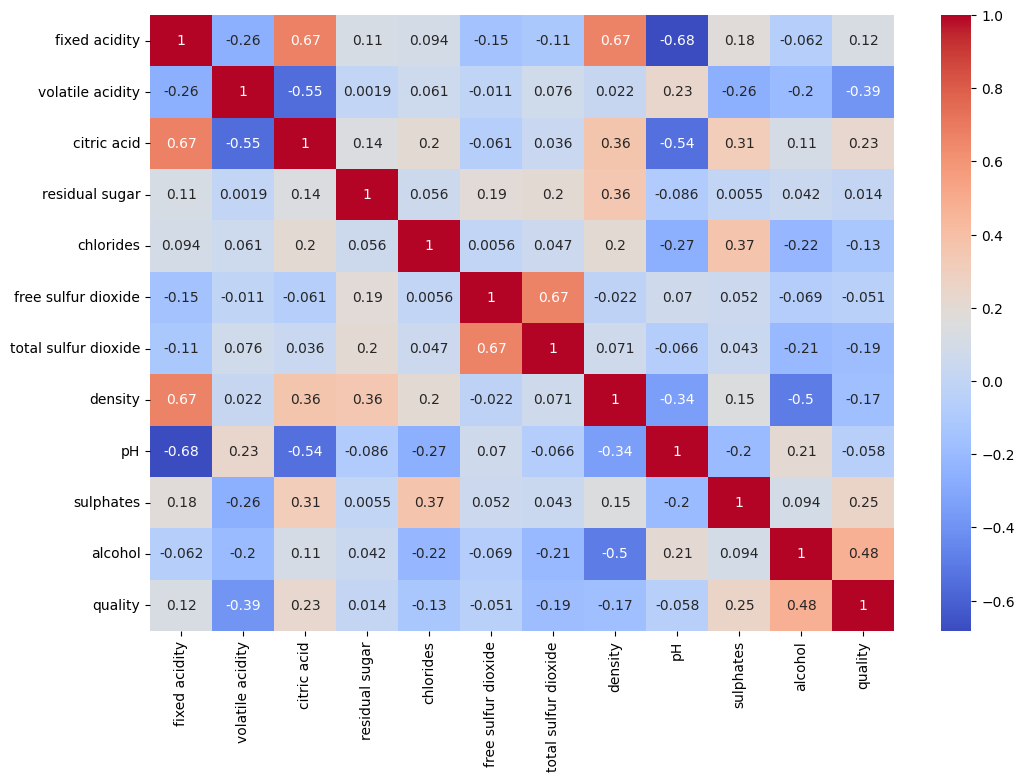

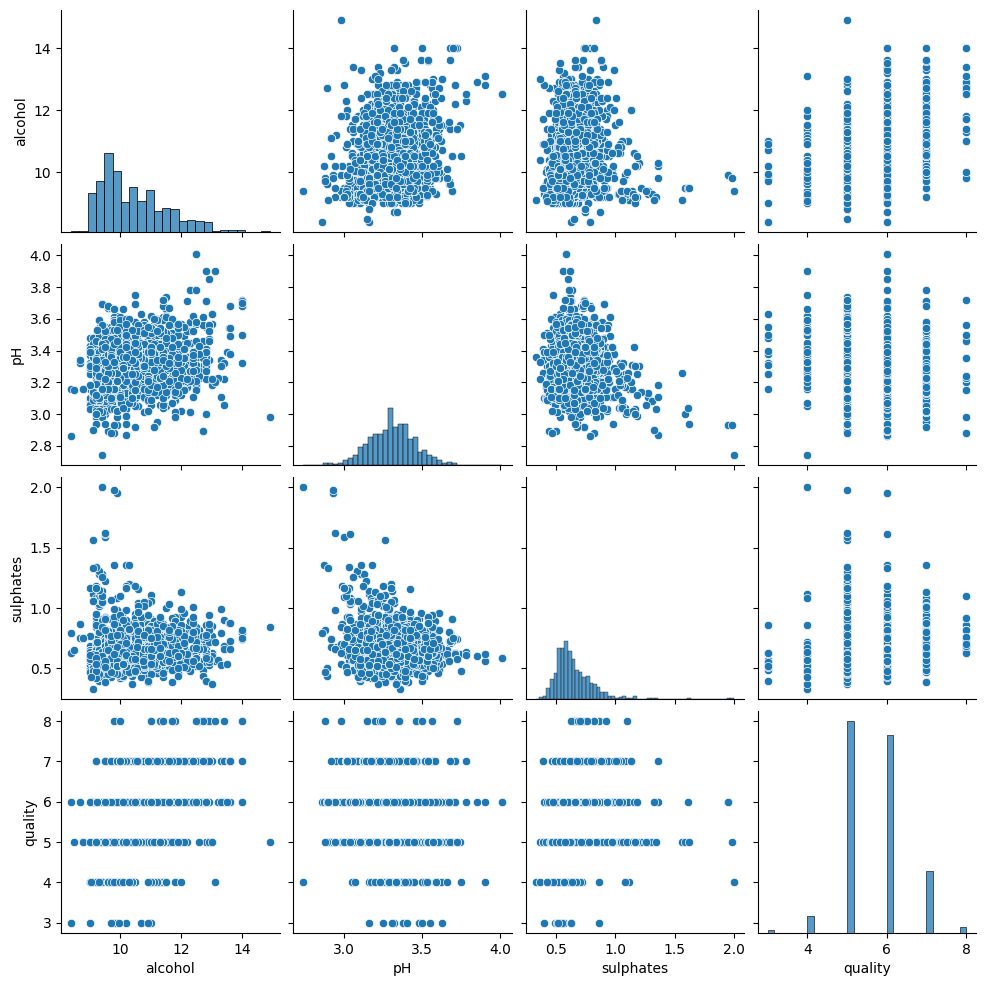

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# Pairplot for selected features
sns.pairplot(df[['alcohol', 'pH', 'sulphates', 'quality']])


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Example: Predicting quality from alcohol
X = df[['alcohol']]
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: 0.23561797203963397
MSE: 0.4995281340730443


In [9]:
# Use all features except 'quality'
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

print("R² Score (MLR):", r2_score(y_test, y_pred_mlr))
print("MSE (MLR):", mean_squared_error(y_test, y_pred_mlr))


R² Score (MLR): 0.40318034127962254
MSE (MLR): 0.3900251439639545


In [10]:
# Coefficients for each feature
pd.DataFrame({'Feature': X.columns, 'Coefficient': mlr.coef_})


,Feature,Coefficient
0,fixed acidity,0.023085
1,volatile acidity,-1.001304
2,citric acid,-0.140821
3,residual sugar,0.006564
4,chlorides,-1.806503
5,free sulfur dioxide,0.005627
6,total sulfur dioxide,-0.003644
7,density,-10.351594
8,pH,-0.393688
9,sulphates,0.841172


In [12]:
# Save predictions
results = X_test.copy()
results['Actual_Quality'] = y_test
results['Predicted_Quality'] = y_pred_mlr
results.to_csv("wine_quality_predictions.csv", index=False)

# Download
files.download("wine_quality_predictions.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>